In [3]:
import os, sys
os.chdir("..")
os.getcwd()

'/home/yyao01'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from ripser import ripser  # type: ignore
from persim import plot_diagrams

from trajectory import World
from dreimac import CircularCoords # type: ignore
from toroidal_coordinates.compute_coord import interp_arr, visualize_tor_coords_x_traj

from scipy.spatial.distance import cdist, pdist, squareform
import math
from toroidal_coordinates.Gardner_toroidal import Gardner_coord
from utils import *
from distance_computation import preprocess_Gardner, preprocess, computeDistanceMatrix_Gardner, computeDistance_from_preprocessed_Gardner

In [5]:
from toroidal_coordinates.toroidal_lifting import *
from copy import *

# on simulated data

In [6]:
num_holes = 0
grid_path = f"../grid_fields/world_{num_holes}holes"
traj_path = f"../trajectory/random_walk_{num_holes}holes.pkl"

In [7]:
grid_rates = pickle.load(
        open(os.path.join(grid_path, "simulation_result.pkl"), "rb")).T

FileNotFoundError: [Errno 2] No such file or directory: '../grid_fields/world_0holes/simulation_result.pkl'

In [ ]:
grid_rates = grid_rates[::10, :]
grid_rates.shape

In [ ]:
traj = pickle.load(open(traj_path, "rb"))[0]
xx, yy = traj[:, 0], traj[:, 1]

xx = interp_arr(xx, grid_rates.shape[0])
yy = interp_arr(yy, grid_rates.shape[0])

xx.shape, yy.shape

((60000,), (60000,))

60000 time points for 2,464 grid cells

In [ ]:
grid_rates.shape

(60000, 2464)

In [ ]:
cc = CircularCoords(grid_rates, 200, prime=47)

KeyboardInterrupt: 

In [ ]:
coords = np.concatenate([cc.get_coordinates(cocycle_idx=0)[:, np.newaxis], cc.get_coordinates(cocycle_idx=1)[:, np.newaxis]], axis=1)
times = np.arange(grid_rates.shape[0])
coords

array([[5.50862816, 0.43724239],
       [5.41867138, 0.57334008],
       [5.33741322, 0.64519196],
       ...,
       [5.58991319, 1.22086174],
       [5.76102054, 1.03685429],
       [5.83622902, 0.87209751]])

(60000, 2)


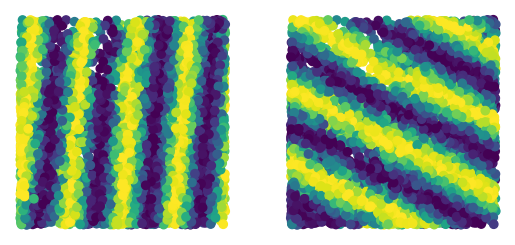

In [10]:

visualize_toroidal_coords(xx, yy, coords, times)

# grid cell experimental data

In [5]:
folder = 'Toroidal_topology_grid_cell_data/'

rat_name, mod_name, sess_name, day_name = ('R', '1', 'OF', 'day2')
sspikes,xx,yy,__,__ = get_spikes(rat_name, mod_name, day_name, sess_name, bType = 'pure',
                                            bSmooth = True, bSpeed = True, folder = folder )

126,728 time points for 111 grid cells

## Using the old distance (from UMAP)
n = 1200, default

In [6]:
# this is the old distance computation, using UMAP
times_cube, population_activity, movetimes, indstemp, dim_red_spikes_move_scaled, dim_red_spikes_move_scaled2 = preprocess_Gardner(sspikes)
d = computeDistance_from_preprocessed_Gardner(dim_red_spikes_move_scaled2)

/home/hyoon/GridCellDecoding/distance_computation.py:155: RuntimeWarning: divide by zero encountered in log
  d = -np.log(result.toarray())


In [7]:
persistence0 = ripser(d,
        maxdim=1,
        coeff=47,
        do_cocycles=True,
        distance_matrix=True,
    )

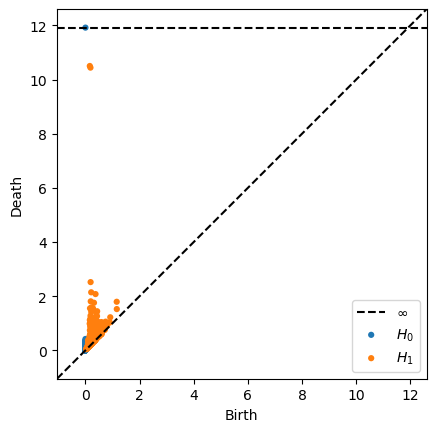

In [8]:
plt.figure()
plot_diagrams(persistence0["dgms"])
plt.show()

<b> Circular coordinates using DREIMAC </b>

coords.shape:  (1200, 2)
(1200, 2)


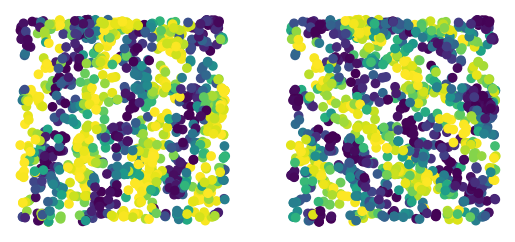

In [9]:
cc = CircularCoords(d, 200, prime=47, distance_matrix= True)
coords = np.concatenate([cc.get_coordinates(cocycle_idx=0)[:, np.newaxis], cc.get_coordinates(cocycle_idx=1)[:, np.newaxis]], axis=1)
print("coords.shape: ", coords.shape)
times = movetimes[indstemp].tolist()
plottimes = np.arange(len(times))
visualize_tor_coords_x_traj(xx[times], yy[times], coords, plottimes)

In [24]:
coords.max()

6.281903743668379

In [25]:
coords.min()

0.0023003897943295656

<b> Circular coordinates using Gridcelltorus </b>

In [10]:
persistence = persistence0
num_circ = 2
dec_tresh = 0.99
ph_classes = [0, 1]
coeff = 47 
############ Decode cocycles ################
diagrams = persistence["dgms"] # the multiset describing the lives of the persistence classes
cocycles = persistence["cocycles"][1] # the cocycle representatives for the 1-dim classes
dists_land = persistence["dperm2all"] # the pairwise distance between the points 
births1 = diagrams[1][:, 0] #the time of birth for the 1-dim classes
deaths1 = diagrams[1][:, 1] #the time of death for the 1-dim classes
deaths1[np.isinf(deaths1)] = 0
lives1 = deaths1-births1 # the lifetime for the 1-dim classes
iMax = np.argsort(lives1)
coords1 = np.zeros((num_circ, len(indstemp)))
threshold = births1[iMax[-2]] + (deaths1[iMax[-2]] - births1[iMax[-2]])*dec_tresh
for c in ph_classes:
    cocycle = cocycles[iMax[-(c+1)]]
    coords1[c,:],inds = get_coords(cocycle, threshold, len(indstemp), dists_land, coeff)



(1200, 2)


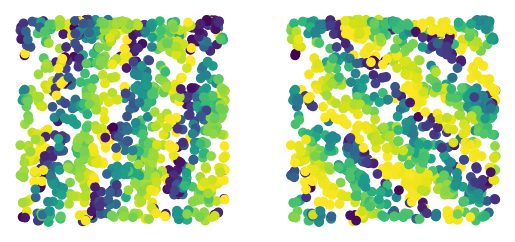

In [11]:
times = movetimes[indstemp].tolist()
plottimes = np.arange(len(times))
visualize_tor_coords_x_traj(xx[times], yy[times], coords1.T, plottimes)

In [26]:
coords1.max()

0.9990178189855166

In [27]:
coords1.min()

0.0004912981665767303

## Using the simplified distance

In [12]:
# simplified distance computation
times_cube, population_activity, movetimes, indstemp, dim_red_spikes_move_scaled, dim_red_spikes_move_scaled2 = preprocess_Gardner(sspikes)
# This is used to compute the distance matrix
dim_red_spikes_move_scaled2.shape

In [14]:
d_simplified = squareform(pdist(dim_red_spikes_move_scaled2, "cosine"))

In [15]:
persistence_simplified = ripser(d_simplified,
        maxdim=1,
        coeff=47,
        do_cocycles=True,
        distance_matrix=True,
    )

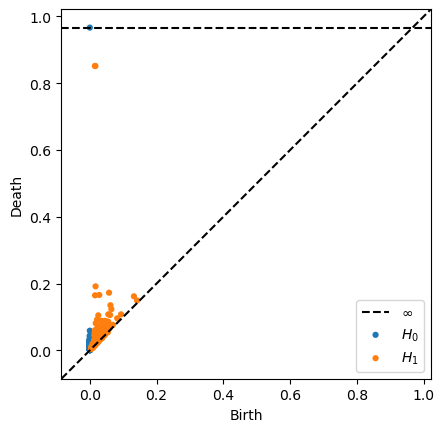

In [16]:
plt.figure()
plot_diagrams(persistence_simplified["dgms"])
plt.show()

In [17]:
np.sort(persistence_simplified["dgms"][1][:,1] - persistence_simplified["dgms"][1][:,0])[-5:]
# the two significant orange points just look overlapped

array([0.13742766, 0.14908045, 0.1744248 , 0.83477671, 0.83652518])

<b> Circular coordinates using DREIMAC </b>

coords.shape:  (1200, 2)
(1200, 2)


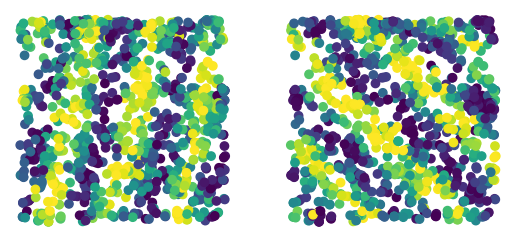

In [18]:
cc = CircularCoords(d_simplified, 200, prime=47, distance_matrix= True)
coords = np.concatenate([cc.get_coordinates(cocycle_idx=0)[:, np.newaxis], cc.get_coordinates(cocycle_idx=1)[:, np.newaxis]], axis=1)
print("coords.shape: ", coords.shape)
times = movetimes[indstemp].tolist()
plottimes = np.arange(len(times))
visualize_tor_coords_x_traj(xx[times], yy[times], coords, plottimes)

<b> Circular coordinates using Gridcelltorus </b>

In [41]:
coords1 = decode_cocycles_Gardner(persistence)

(1200, 2)


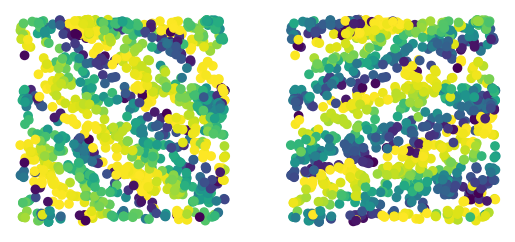

In [42]:
times = movetimes[indstemp].tolist()
plottimes = np.arange(len(times))
visualize_tor_coords_x_traj(xx[times], yy[times], coords1.T, plottimes)

The circular coordinates from Gardner paper is in the range [0,1], and the colors change abruptly.
Note that `visualize_tor_coords_x_traj` applies some trig function (`cos`) to the obtained circular coordinates before plotting them. So we need to convert the circular coordinates from the Gardner paper into range [0, 2 pi]

(1200, 2)


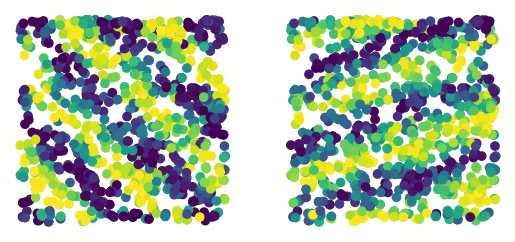

In [39]:
times = movetimes[indstemp].tolist()
plottimes = np.arange(len(times))
visualize_tor_coords_x_traj(xx[times], yy[times], (coords1 * 2 * math.pi).T, plottimes)

# Experiments

In [79]:
def decode_cocycles_Gardner(persistence, indstemp,
                            num_circ = 2,
                            dec_tresh = 0.99,
                            ph_classes = [0, 1],
                            coeff = 47):

    ############ Decode cocycles ################
    diagrams = persistence["dgms"] # the multiset describing the lives of the persistence classes
    cocycles = persistence["cocycles"][1] # the cocycle representatives for the 1-dim classes
    dists_land = persistence["dperm2all"] # the pairwise distance between the points 
    births1 = diagrams[1][:, 0] #the time of birth for the 1-dim classes
    deaths1 = diagrams[1][:, 1] #the time of death for the 1-dim classes
    deaths1[np.isinf(deaths1)] = 0
    lives1 = deaths1-births1 # the lifetime for the 1-dim classes
    iMax = np.argsort(lives1)
    coords1 = np.zeros((num_circ, len(indstemp)))
    threshold = births1[iMax[-2]] + (deaths1[iMax[-2]] - births1[iMax[-2]])*dec_tresh
    for c in ph_classes:
        cocycle = cocycles[iMax[-(c+1)]]
        coords1[c,:],inds = get_coords(cocycle, threshold, len(indstemp), dists_land, coeff)
    
    return coords1


In [86]:
def get_circular_coord_experiment_data(rat_name, mod_name, sess_name, day_name,
    dim = 6,
    ph_classes = [0,1], # Decode the ith most persistent cohomology class
    num_circ = len(ph_classes),
    dec_tresh = 0.99,
    metric = 'cosine',
    maxdim = 1,
    coeff = 47,
    active_times = 15000,
    k = 1000,
    num_times = 5,
    n_points = 1200,
    nbs = 800):
    # sigma = 1500

    sspikes,xx,yy,__,__ = get_spikes(rat_name, mod_name, day_name, sess_name, bType = 'pure',
                                            bSmooth = True, bSpeed = True, folder = folder )

    times_cube, population_activity, movetimes, indstemp, dim_red_spikes_move_scaled, dim_red_spikes_move_scaled2 = preprocess_Gardner(sspikes, n_points = n_points)

    ### Compute the two distances
    # compute old distance involving UMAP
    d = computeDistance_from_preprocessed_Gardner(dim_red_spikes_move_scaled2)
    # compute the simplified distance
    d_simplified = squareform(pdist(dim_red_spikes_move_scaled2, "cosine"))

    ### compute circular coordinates from DREIMAC 
    cc = CircularCoords(d, 200, prime=47, distance_matrix= True)
    coords_DREIMAC_d = np.concatenate([cc.get_coordinates(cocycle_idx=0)[:, np.newaxis], cc.get_coordinates(cocycle_idx=1)[:, np.newaxis]], axis=1)

    cc = CircularCoords(d_simplified, 200, prime=47, distance_matrix= True)
    coords_DREIMAC_d_simplified = np.concatenate([cc.get_coordinates(cocycle_idx=0)[:, np.newaxis], cc.get_coordinates(cocycle_idx=1)[:, np.newaxis]], axis=1)
       
    ### compute circular coordinates from the grid cell torus code
    persistence = ripser(d,
        maxdim=1,
        coeff=47,
        do_cocycles=True,
        distance_matrix=True,
    )

    coords_Gardner_d = decode_cocycles_Gardner(persistence, indstemp)
    
    persistence_simplified = ripser(d_simplified,
        maxdim=1,
        coeff=47,
        do_cocycles=True,
        distance_matrix=True,
    )
    coords_Gardner_d_simplified = decode_cocycles_Gardner(persistence_simplified,indstemp)
    
    
    
    return d, d_simplified, sspikes, xx, yy, movetimes, indstemp, coords_DREIMAC_d, coords_DREIMAC_d_simplified, coords_Gardner_d, coords_Gardner_d_simplified

In [51]:
folder = 'Toroidal_topology_grid_cell_data/'

rat_name, mod_name, sess_name, day_name = ('R', '1', 'OF', 'day2')

d, d_simplified, sspikes, xx, yy, movetimes, indstemp, coords_DREIMAC_d, coords_DREIMAC_d_simplified, coords_Gardner_d, coords_Gardner_d_simplified = get_circular_coord_experiment_data(rat_name, mod_name, sess_name, day_name)


/home/hyoon/GridCellDecoding/distance_computation.py:155: RuntimeWarning: divide by zero encountered in log
  d = -np.log(result.toarray())


Plot circ coordiantes  from DREIMAC

(1200, 2)


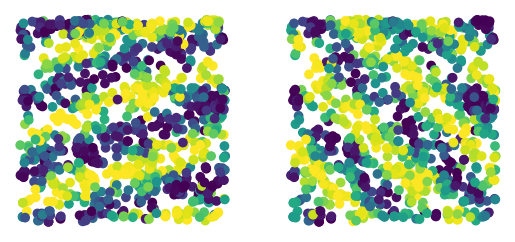

In [52]:
times = movetimes[indstemp].tolist()
plottimes = np.arange(len(times))
visualize_tor_coords_x_traj(xx[times], yy[times], coords_DREIMAC_d, plottimes)

(1200, 2)


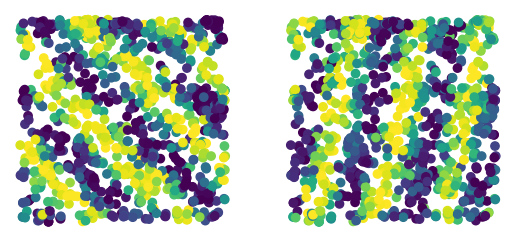

In [53]:
visualize_tor_coords_x_traj(xx[times], yy[times], coords_DREIMAC_d_simplified, plottimes)

Plot circ coordinates fro mGardner

(1200, 2)


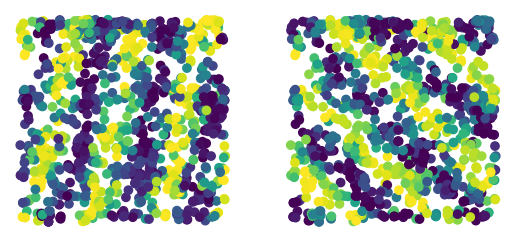

In [54]:
visualize_tor_coords_x_traj(xx[times], yy[times], (coords_Gardner_d * 2 * math.pi).T, plottimes)

(1200, 2)


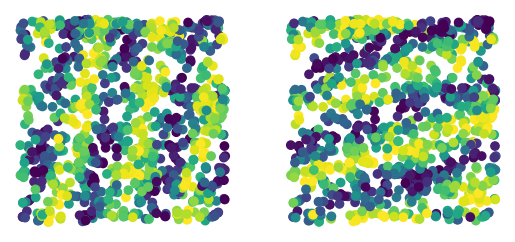

In [55]:
visualize_tor_coords_x_traj(xx[times], yy[times], (coords_Gardner_d_simplified * 2 * math.pi).T, plottimes)

# Increasing the number of time points selected 

In [87]:
folder = 'Toroidal_topology_grid_cell_data/'

rat_name, mod_name, sess_name, day_name = ('R', '1', 'OF', 'day2')
n_points = 4000

d, d_simplified, sspikes, xx, yy, movetimes, indstemp, coords_DREIMAC_d, coords_DREIMAC_d_simplified, coords_Gardner_d, coords_Gardner_d_simplified = get_circular_coord_experiment_data(rat_name, mod_name, sess_name, day_name, 
                                                                                                                                                                                         n_points = n_points)


/home/hyoon/GridCellDecoding/distance_computation.py:155: RuntimeWarning: divide by zero encountered in log
  d = -np.log(result.toarray())
/home/hyoon/anaconda3/lib/python3.11/site-packages/dreimac/emcoords.py:183: RuntimeWarning: invalid value encountered in divide
  varphi = phi / denom[None, :]
/home/hyoon/anaconda3/lib/python3.11/site-packages/dreimac/emcoords.py:183: RuntimeWarning: invalid value encountered in divide
  varphi = phi / denom[None, :]


(4000, 2)


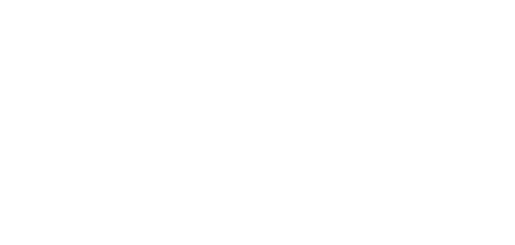

In [88]:
times = movetimes[indstemp].tolist()
plottimes = np.arange(len(times))
visualize_tor_coords_x_traj(xx[times], yy[times], coords_DREIMAC_d, plottimes)

In [93]:
d

array([[ 0.        ,         inf,  8.3380832 , ...,         inf,
                inf, 54.76476957],
       [        inf,  0.        ,         inf, ...,         inf,
                inf,         inf],
       [ 8.3380832 ,         inf,  0.        , ...,         inf,
                inf,         inf],
       ...,
       [        inf,         inf,         inf, ...,  0.        ,
                inf, 27.57132968],
       [        inf,         inf,         inf, ...,         inf,
         0.        , 10.43702962],
       [54.76476957,         inf,         inf, ..., 27.57132968,
        10.43702962,  0.        ]])

The `d` matrix is almost all inf

(4000, 2)


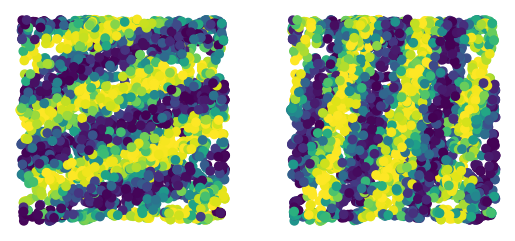

In [89]:
visualize_tor_coords_x_traj(xx[times], yy[times], coords_DREIMAC_d_simplified, plottimes)

Plot circ coordinates fro mGardner

(4000, 2)


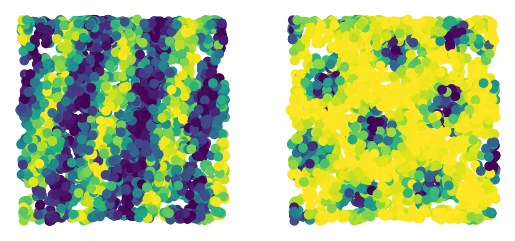

In [90]:
visualize_tor_coords_x_traj(xx[times], yy[times], (coords_Gardner_d * 2 * math.pi).T, plottimes)

(4000, 2)


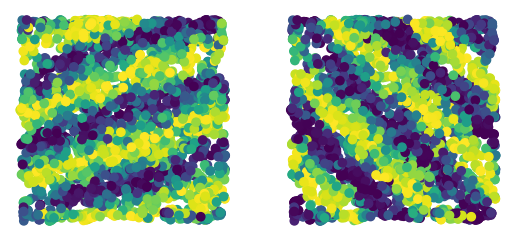

In [91]:
visualize_tor_coords_x_traj(xx[times], yy[times], (coords_Gardner_d_simplified * 2 * math.pi).T, plottimes)

## Interpolate to all time intervals (using Gardner's method)


In [199]:
def interpolate_circular_coord_Gardner(sspikes, movetimes, indstemp, coords1, n_points = 1200,):
    
    num_neurons = len(sspikes[0,:])
    centcosall = np.zeros((num_neurons, 2, n_points))
    centsinall = np.zeros((num_neurons, 2, n_points))
    dspk = preprocessing.scale(sspikes[movetimes[indstemp],:])

    for neurid in range(num_neurons):
        spktemp = dspk[:, neurid].copy()
        centcosall[neurid,:,:] = np.multiply(np.cos(coords1[:, :]*2*np.pi),spktemp)
        centsinall[neurid,:,:] = np.multiply(np.sin(coords1[:, :]*2*np.pi),spktemp)

    times = np.where(np.sum(sspikes>0, 1)>=1)[0]
    dspk = preprocessing.scale(sspikes)
    sspikes = sspikes[times,:]
    dspk = dspk[times,:]

    a = np.zeros((len(sspikes[:,0]), 2, num_neurons))
    for n in range(num_neurons):
        a[:,:,n] = np.multiply(dspk[:,n:n+1],np.sum(centcosall[n,:,:],1))

    
    cc = np.zeros((len(sspikes[:,0]), 2, num_neurons))
    for n in range(num_neurons):
        cc[:,:,n] = np.multiply(dspk[:,n:n+1],np.sum(centsinall[n,:,:],1))

    mtot2 = np.sum(cc,2)
    mtot1 = np.sum(a,2)
    coords = np.arctan2(mtot2,mtot1)%(2*np.pi)
    coordsbox = coords.copy()
    times_box = times.copy()

    return coordsbox, times_box, centcosall, centsinall

In [210]:
coordsbox_DREIMAC_simplified, _, _, _ = interpolate_circular_coord_Gardner(sspikes, movetimes, indstemp, coords_DREIMAC_d_simplified.T, n_points = n_points)
coordsbox_Gardner_simplified, _, _, _ = interpolate_circular_coord_Gardner(sspikes, movetimes, indstemp, coords_Gardner_d_simplified, n_points = n_points)

In [211]:
# lift paths
lifted_coords_DREIMAC_simplified = toroidal_lifting_distance(deepcopy(coordsbox_DREIMAC_simplified))
lifted_coords_Gardner_simplified = toroidal_lifting_distance(deepcopy(coordsbox_Gardner_simplified))

In [213]:
lifted_coords_DREIMAC_simplified.shape

(126728, 2)

## Observe a specific time interval

<b> note: </b> All paths start at dark and move towards bright yellow

<Figure size 640x480 with 0 Axes>

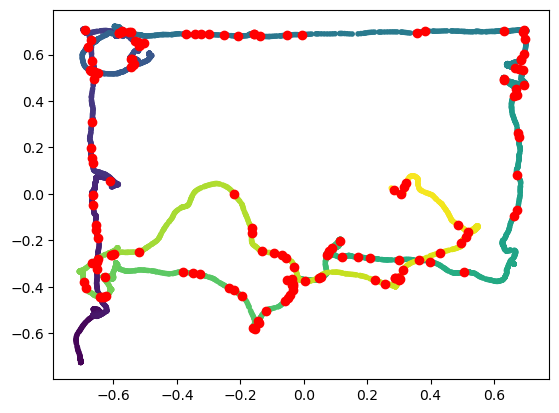

<Figure size 640x480 with 0 Axes>

In [198]:
# plot the included timepoints in a section of the interval 
initial = 2000
final = initial + 5000
timepoints_in_interval = [x for x in times if x > initial and x < final]

colors = plt.cm.viridis(np.linspace(0, 1, min(xx.shape[0], final-initial)))

plt.figure()
plt.scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
plt.scatter(xx[timepoints_in_interval], yy[timepoints_in_interval], color = "red", label = "selected timepoints")
plt.figure()

In [ ]:
# plot example path and lifted path (after making the sspikes 10 times longer) 
initial = 2000
final = initial + 5000

initial_10 = initial * 10
final_10 = final * 10

colors10 = plt.cm.viridis(np.linspace(0, 1, final_10-initial_10))
colors = plt.cm.viridis(np.linspace(0, 1, final-initial))

timepoints_in_interval = [x for x in times if x > initial and x < final]
timepoints_idx = [idx for (idx, x) in enumerate(times) if x > initial and x < final]

timepoints_in_interval10 = [x for x in times10 if x > initial_10 and x < final_10]
timepoints_idx_10 = [idx for (idx, x) in enumerate(times10) if x > initial_10 and x < final_10]


fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (9,9))
ax[0,0].scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
ax[0,0].scatter(xx[timepoints_in_interval], yy[timepoints_in_interval], color = "red")
ax[0,0].set_title("original path, timepoints selected from sspikes")

ax[0,1].scatter(xx10[initial_10:final_10], yy10[initial_10:final_10], marker='.', color=colors10)
ax[0,1].scatter(xx10[timepoints_in_interval10], yy10[timepoints_in_interval10], color = "red")
ax[0,1].set_title("original path, timepoints selected from sspikes 10")


ax[1,0].scatter(lifted_coords[initial:final, 0], lifted_coords[initial:final, 1], marker='.', color=colors)
ax[1,0].scatter(lifted_coords[timepoints_in_interval, 0], lifted_coords[timepoints_in_interval, 1],color = "red")
ax[1,0].set_title("lifted from sspikes")

ax[1,1].scatter(lifted_coords_10[initial_10:final_10, 0], lifted_coords_10[initial_10:final_10, 1], marker='.', color=colors10)
ax[1,1].scatter(lifted_coords_10[timepoints_in_interval10, 0], lifted_coords_10[timepoints_in_interval10, 1],color = "red")
ax[1,1].set_title("lifted from sspikes 10")


plt.show()

In [97]:
xx.shape

(126728,)

In [98]:
yy.shape

(126728,)

Comparing to the notebook "Gardner_lifting_test_Yoon", scale differs by a factor of 10

<Figure size 640x480 with 0 Axes>

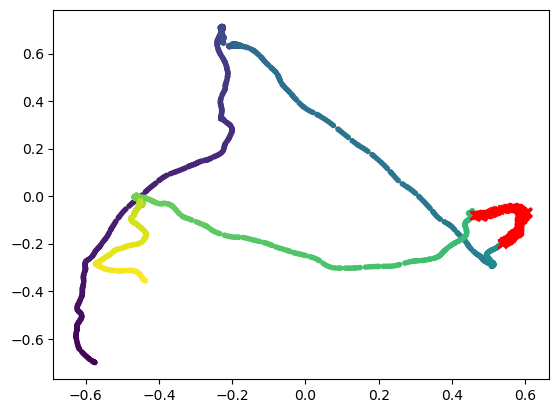

<Figure size 640x480 with 0 Axes>

In [112]:
initial = 10000
final = initial + 2000

subsection_initial = 11000
subsection_final = 11300

colors = plt.cm.viridis(np.linspace(0, 1, min(xx.shape[0], final-initial)))

plt.figure()
plt.scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
plt.scatter(xx[subsection_initial:subsection_final], yy[subsection_initial:subsection_final], marker = 'x', color = "red")
plt.figure()


<Figure size 640x480 with 0 Axes>

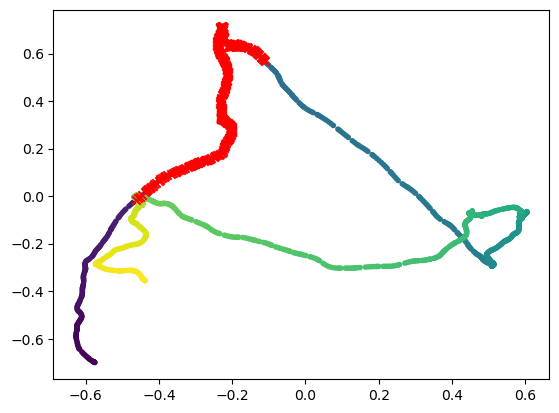

<Figure size 640x480 with 0 Axes>

In [161]:
initial = 10000
final = initial + 2000

subsection_initial = 10180
subsection_final = 10710

colors = plt.cm.viridis(np.linspace(0, 1, min(xx.shape[0], final-initial)))

plt.figure()
plt.scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
plt.scatter(xx[subsection_initial:subsection_final], yy[subsection_initial:subsection_final], marker = 'x', color = "red")
plt.figure()

<Figure size 640x480 with 0 Axes>

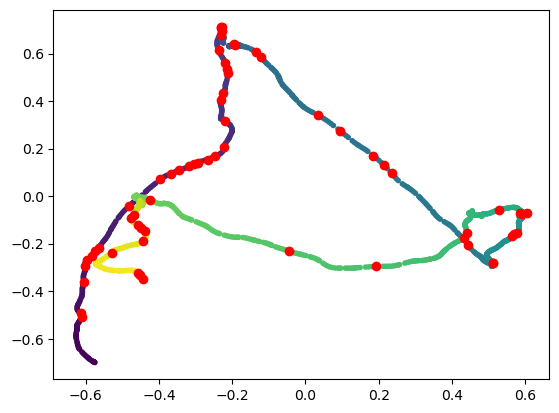

<Figure size 640x480 with 0 Axes>

In [162]:
# plot  the timepoints in which the toroidal coordinates are computed

# plot the included timepoints in a section of the interval 
initial = 10000
final = initial + 2000
timepoints_in_interval = [x for x in times if x > initial and x < final]
timepoints_idx = [idx for (idx, x) in enumerate(times) if x > initial and x < final]

colors = plt.cm.viridis(np.linspace(0, 1, min(xx.shape[0], final-initial)))

plt.figure()
plt.scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
plt.scatter(xx[timepoints_in_interval], yy[timepoints_in_interval], color = "red", label = "selected timepoints")
plt.figure()


Lift at time intervals that are dense enough

<Figure size 640x480 with 0 Axes>

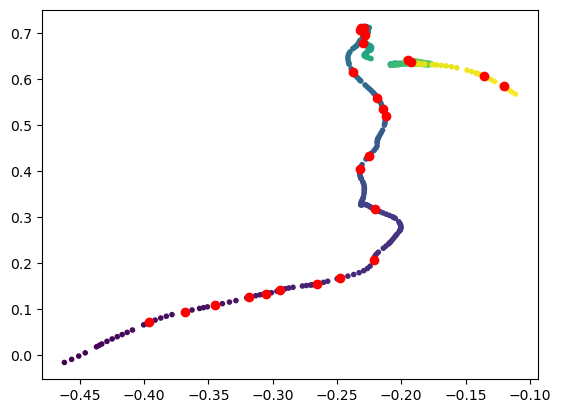

<Figure size 640x480 with 0 Axes>

In [163]:
# plot  the timepoints in which the toroidal coordinates are computed

# plot the included timepoints in a section of the interval 

initial = 10180
final = 10710

timepoints_in_interval = [x for x in times if x > initial and x < final]
timepoints_idx = [idx for (idx, x) in enumerate(times) if x > initial and x < final]

colors = plt.cm.viridis(np.linspace(0, 1, min(xx.shape[0], final-initial)))

plt.figure()
plt.scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
plt.scatter(xx[timepoints_in_interval], yy[timepoints_in_interval], color = "red", label = "selected timepoints")
plt.figure()


(25, 2)


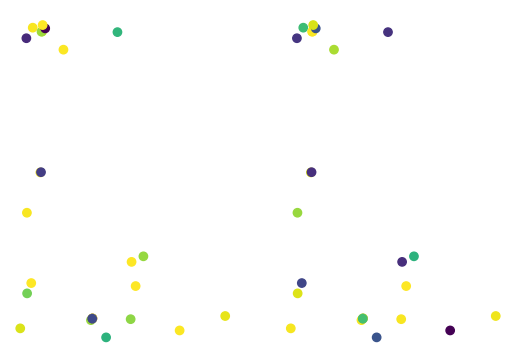

In [181]:
visualize_tor_coords_x_traj(xx[timepoints_idx], yy[timepoints_idx], coords_DREIMAC_d_simplified[timepoints_idx,:], np.arange(len(timepoints_idx)))

In [164]:
lifted_coords = toroidal_lifting_distance(deepcopy(coords_DREIMAC_d_simplified))

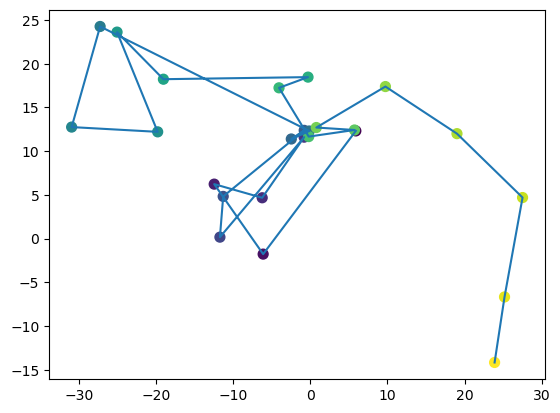

In [165]:
colors = plt.cm.viridis(np.linspace(0, 1, len(timepoints_idx)))
plt.plot(lifted_coords[timepoints_idx, 0], lifted_coords[timepoints_idx, 1])
plt.scatter(lifted_coords[timepoints_idx, 0], lifted_coords[timepoints_idx, 1], marker='.', color=colors, s = 200)
#plt.scatter(smoothed_lifted_coords[subsection_initial:subsection_final, 0], smoothed_lifted_coords[subsection_initial:subsection_final, 1], marker = 'x', color = "red")
#plt.savefig(os.path.join(figure_path, "lifted_segment.png"), dpi=300)
#plt.savefig("Gardner_lifting_test_outputs/lift.png")
#plt.show()

<Figure size 640x480 with 0 Axes>

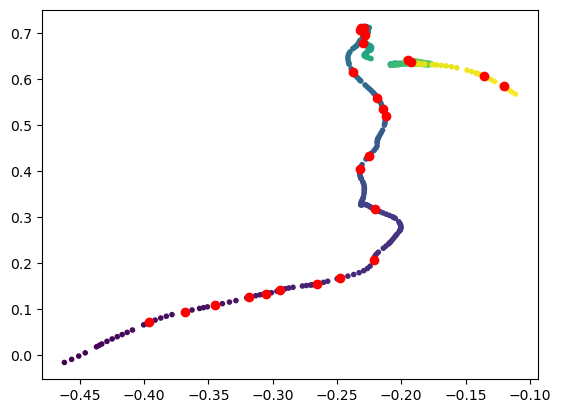

<Figure size 640x480 with 0 Axes>

In [167]:
# plot  the timepoints in which the toroidal coordinates are computed

# plot the included timepoints in a section of the interval 

initial = 10180
final = 10710

timepoints_in_interval = [x for x in times if x > initial and x < final]
timepoints_idx = [idx for (idx, x) in enumerate(times) if x > initial and x < final]

colors = plt.cm.viridis(np.linspace(0, 1, min(xx.shape[0], final-initial)))

plt.figure()
plt.scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
plt.scatter(xx[timepoints_in_interval], yy[timepoints_in_interval], color = "red", label = "selected timepoints")
plt.figure()


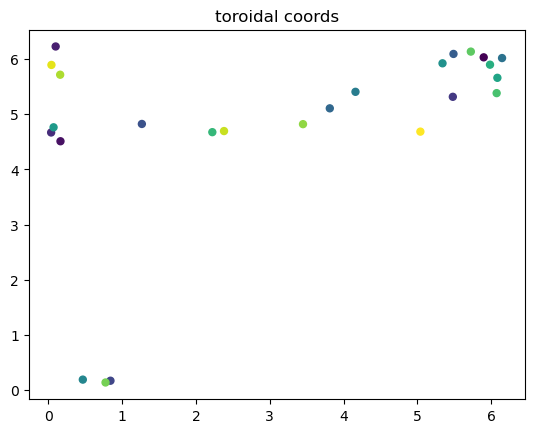

In [177]:
plt.figure
subsection_colors = plt.cm.viridis(np.linspace(0, 1, len(timepoints_idx)))
plt.scatter(coords_DREIMAC_d_simplified[timepoints_idx, 0], coords_DREIMAC_d_simplified[timepoints_idx, 1], marker='.', s = 100, color =subsection_colors)
plt.title("toroidal coords")
plt.show()

In [196]:
lifted_coords.shape

(4000, 2)

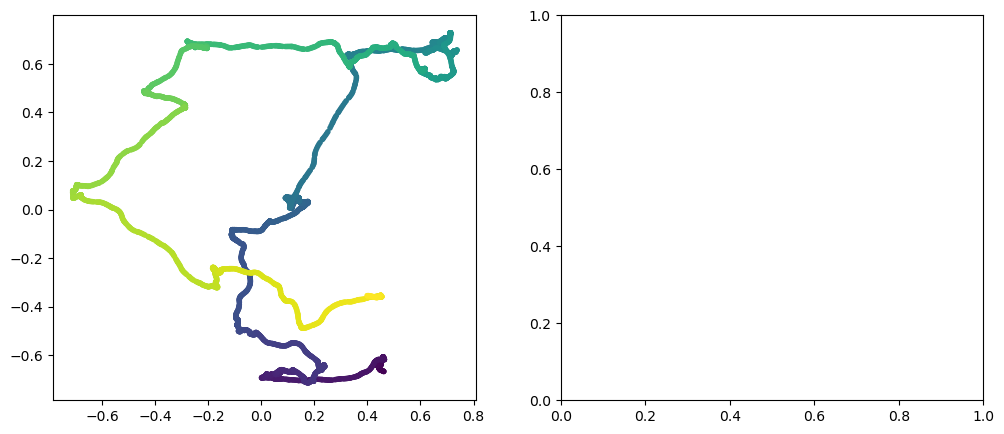

In [194]:
initial = 20000
final = initial + 5000

colors = plt.cm.viridis(np.linspace(0, 1, final-initial))

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 5))
ax[0].scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
ax[0].scatter(lifted_coors[
#plt.scatter(lifted_coords[initial:final, 0], lifted_coords[initial:final, 1], marker='.', color=colors)
plt.show()

# What happens if I just select time points at regular intervals
* just use "active times", instead of "indstemp"
* The PH calculation is not as clean

In [18]:
n_points = 6000
active_times = 15000
times_cube, population_activity, movetimes, indstemp, dim_red_spikes_move_scaled, dim_red_spikes_move_scaled2 = preprocess_Gardner(sspikes, n_points = n_points, active_times = active_times)
print("shape of dim reduced matrix: ", dim_red_spikes_move_scaled.shape)

shape of dim reduced matrix:  (15000, 6)


In [19]:
d_simplified = squareform(pdist(dim_red_spikes_move_scaled, "cosine"))

In [ ]:
persistence_simplified = ripser(d_simplified,
        maxdim=1,
        coeff=47,
        do_cocycles=True,
        distance_matrix=True,
    )
plt.figure()
plot_diagrams(persistence_simplified["dgms"])
plt.show()